#### Underfitting - Overfitting
<img src="images/overfitting_underfitting.png" width=600> \
- Overfitting: high variance ~ a lot of variances of model for prediction ~ the predictions change significantly when trained on different dataset. \
- Underfitting: high bias ~ the bias = the difference of the expected value of the model (E[f_hat(x)]) vs the truth data/value. \
- One way of finiding a good bias-variance trade-off is to tune the complexity of the model via regularization.

#### The L2 Regularization
- Shrink weights, not kill weights (not sparse)
- Formula: **lambda** is the regularization parameter. By increasing **lambda**, we increase the regularization strength\
<img src="images/l2_regularizer.png" width=200> 
- The loss function for Logistic Regression become: \
<img src="images/new_loss_function.png" width=400> 
- The derivative for update term become: \
<img src="images/loss_function_derivative_with_l2.png" width=300> 
- Regularization is another reason why feature scaling such as standardization is important. For Regularization to work, all the features need to be on comparable scales.
- The term **C** in LogisticRegression in sklearn is inverse proportional to **lambda**. So if C is small -> the regularization is strong.

In [5]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from classification_algos.make_data import generate_iris_data
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_test = generate_iris_data(num_class="multi")
X_train_2_features = X_train[:, :2]
X_test_2_features = X_test[:, :2]

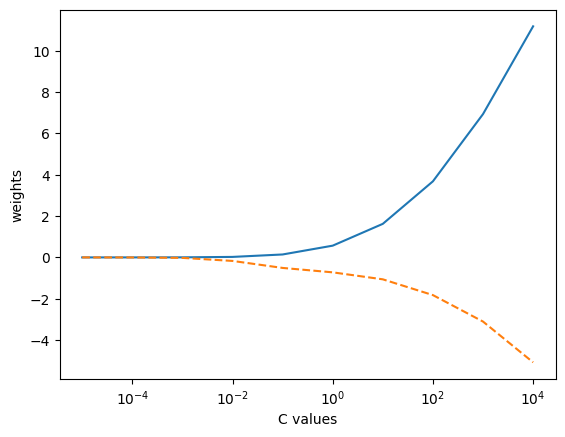

In [19]:
weights, C_params = [], []

for c in np.arange(-5, 5):
    model = LogisticRegression(C=10.**c)
    model.fit(X_train_2_features, y_train)
    weights.append(model.coef_[1]) # get the set of weights of the first sub model only
    C_params.append(10.**c)

weights = np.array(weights)
# C_params = np.array(C_params)

plt.plot(C_params, weights[:, 0])
plt.plot(C_params, weights[:, 1], linestyle="--")
plt.xlabel("C values")
plt.ylabel("weights")
plt.xscale('log')
plt.show()


In [11]:
# This is using one-over-rest strategy -> 3 classes have 3 sub-models -> 3 sub weights
model.coef_

array([[-24.28873845,  10.3481607 ],
       [ 11.18390217,  -5.0775349 ],
       [ 13.10483627,  -5.2706258 ]])